## **Baseline A: Clinical Features Classification**

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

## 2. Load Clinical Dataset

In [2]:
df = pd.read_csv("cleaned_clinical_features.csv")

print(df.shape)
df.head()

(2429, 9)


,ID,LeftRight,Age,Age_missing,Breast_density_encoded,BI_RADS,Mass_present,Calc_present,target
0,D1-0001,R,44.0,0,2,2,0,1,0
1,D1-0002,L,40.0,0,2,2,0,1,0
2,D1-0003,L,39.0,0,1,3,0,1,0
3,D1-0004,L,41.0,0,2,2,0,1,0
4,D1-0005,R,42.0,0,3,2,0,1,0


## 3. Define Features and Target

In [3]:
X = df.drop(columns=["ID", "LeftRight", "target"])
y = df["target"]

## 4. Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

## 5. Feature Scaling

In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 6. Model 1: Logistic Regression

In [6]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9300411522633745
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       379
           1       0.92      0.93      0.93       350

    accuracy                           0.93       729
   macro avg       0.93      0.93      0.93       729
weighted avg       0.93      0.93      0.93       729



## 7. Model 2: Random Forest

In [7]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9259259259259259
              precision    recall  f1-score   support

           0       0.95      0.91      0.93       379
           1       0.91      0.94      0.92       350

    accuracy                           0.93       729
   macro avg       0.93      0.93      0.93       729
weighted avg       0.93      0.93      0.93       729



## 8. Model 3: Naive Bayes

In [8]:
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.9039780521262003
              precision    recall  f1-score   support

           0       1.00      0.82      0.90       379
           1       0.83      1.00      0.91       350

    accuracy                           0.90       729
   macro avg       0.92      0.91      0.90       729
weighted avg       0.92      0.90      0.90       729



## 9. Model 4: Support Vector Machine

In [9]:
svm = SVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.9286694101508917
              precision    recall  f1-score   support

           0       0.95      0.91      0.93       379
           1       0.91      0.95      0.93       350

    accuracy                           0.93       729
   macro avg       0.93      0.93      0.93       729
weighted avg       0.93      0.93      0.93       729



## 10. Confusion Matrix for BEST model (Logistic Regression)

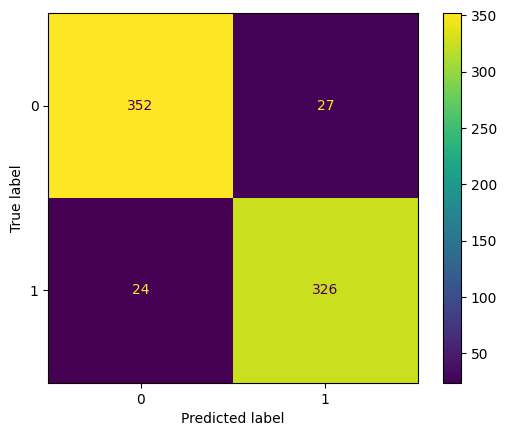

In [10]:
ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test)

## 11. Feature Importance

In [11]:
feature_names = X.columns
coefficients = lr.coef_[0]

for name, coef in sorted(zip(feature_names, coefficients), key=lambda x: abs(x[1]), reverse=True):
    print(name, coef)

BI_RADS 4.164707620939271
Age_missing -1.4557374291499954
Age 0.7610966655706242
Calc_present 0.698055066744919
Breast_density_encoded 0.6131242105876171
Mass_present 0.2619546955724183


## 12. Model Comparison Visualization

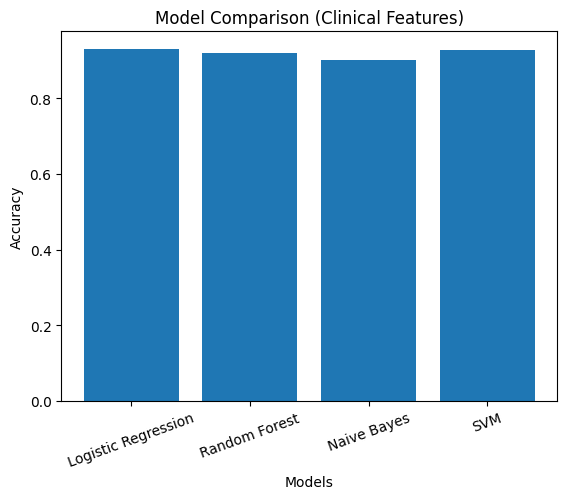

In [12]:
models = ["Logistic Regression", "Random Forest", "Naive Bayes", "SVM"]
accuracies = [0.93, 0.92, 0.90, 0.928]

plt.figure()
plt.bar(models, accuracies)

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison (Clinical Features)")

plt.xticks(rotation=20)
plt.show()

## 13. Feature Importance Plot

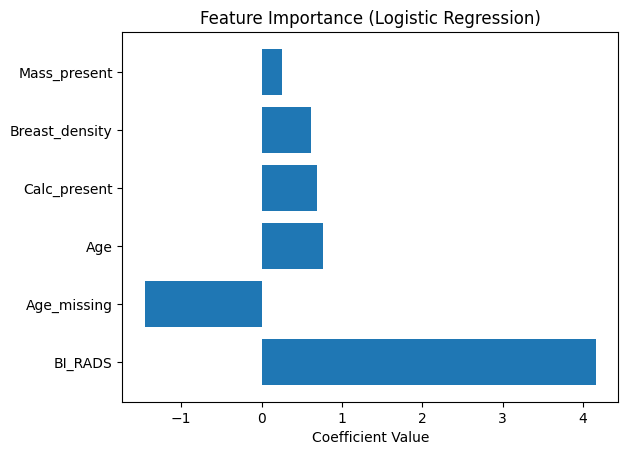

In [13]:
plt.figure()

features = ["BI_RADS", "Age_missing", "Age", "Calc_present", "Breast_density", "Mass_present"]
importance = [4.16, -1.45, 0.76, 0.69, 0.61, 0.26]

plt.barh(features, importance)

plt.xlabel("Coefficient Value")
plt.title("Feature Importance (Logistic Regression)")

plt.show()

## 14. Saving Results

In [ ]:
results = pd.DataFrame({
    "Model": models,
    "Accuracy": accuracies
})

results.to_csv("model_comparison.csv", index=False)